## Del experimento 01 al experimento 02

En el experimento 01, la trenza se construye mediante parámetros que determinan su comportamiento:

PARÁMETROS
     ↓
TRAYECTORIA
     ↓
TRENZA

Los parámetros de **ruido, entropía, torsión, radio y límite** permiten introducir variaciones y restricciones en el recorrido.

En el experimento 02 se propone desplazar esta lógica:

DICCIONARIO
     ↓
OPERACIÓN
     ↓
CAMBIO EN EL RECORRIDO
     ↓
PARÁMETROS
     ↓
TRENZA

El diccionario deja así de funcionar únicamente como referencia conceptual y comienza a ser utilizado como una posible **fuente de operaciones sobre la trayectoria**.

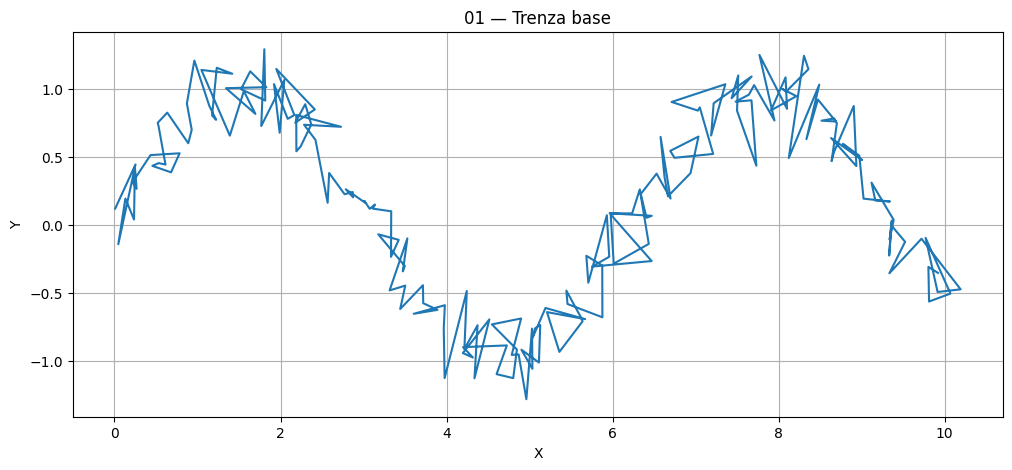

In [6]:
# ============================================================
# 01 — BASE DE LA TRENZA
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# PARÁMETROS
# ------------------------------------------------------------

limite = 200
ruido = 0.15
entropia = 0.20
torsion = 0.10
radio = 1.0

# ------------------------------------------------------------
# TRAYECTORIA BASE
# ------------------------------------------------------------

t = np.linspace(0, 10, limite)

# Recorrido lineal
x = t

# Oscilación que produce el entrelazamiento
y = radio * np.sin(t * torsion * 10)

# ------------------------------------------------------------
# RUIDO
# ------------------------------------------------------------

x = x + np.random.normal(0, ruido, limite)
y = y + np.random.normal(0, ruido, limite)

# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(x, y)

plt.title("01 — Trenza base")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)

plt.show()

In [7]:
# ============================================================
# 02 — DICCIONARIO TTT2
# ============================================================

# 24 unidades del diccionario
# Cada unidad podrá posteriormente asociarse
# a una acción / reacción que modifique la trayectoria.

diccionario = {
    i: {
        "unidad": i,
        "operacion": None
    }
    for i in range(1, 25)
}

# Comprobación
print("Unidades del diccionario:", len(diccionario))

for unidad, datos in diccionario.items():
    print(f"Unidad {unidad}: {datos['operacion']}")

Unidades del diccionario: 24
Unidad 1: None
Unidad 2: None
Unidad 3: None
Unidad 4: None
Unidad 5: None
Unidad 6: None
Unidad 7: None
Unidad 8: None
Unidad 9: None
Unidad 10: None
Unidad 11: None
Unidad 12: None
Unidad 13: None
Unidad 14: None
Unidad 15: None
Unidad 16: None
Unidad 17: None
Unidad 18: None
Unidad 19: None
Unidad 20: None
Unidad 21: None
Unidad 22: None
Unidad 23: None
Unidad 24: None


In [8]:
# ============================================================
# 03 — ESTRUCTURA DE OPERACIONES
# ============================================================

# Cada unidad del diccionario tendrá:
# - una acción
# - un efecto sobre la trayectoria
#
# Todavía dejamos estos valores vacíos porque
# incorporaremos las correspondencias reales de TTT2.

for unidad in diccionario:

    diccionario[unidad]["accion"] = None
    diccionario[unidad]["efecto"] = None


# Mostrar estructura

for unidad, datos in diccionario.items():
    print(
        f"Unidad {unidad} → "
        f"acción: {datos['accion']} | "
        f"efecto: {datos['efecto']}"
    )

Unidad 1 → acción: None | efecto: None
Unidad 2 → acción: None | efecto: None
Unidad 3 → acción: None | efecto: None
Unidad 4 → acción: None | efecto: None
Unidad 5 → acción: None | efecto: None
Unidad 6 → acción: None | efecto: None
Unidad 7 → acción: None | efecto: None
Unidad 8 → acción: None | efecto: None
Unidad 9 → acción: None | efecto: None
Unidad 10 → acción: None | efecto: None
Unidad 11 → acción: None | efecto: None
Unidad 12 → acción: None | efecto: None
Unidad 13 → acción: None | efecto: None
Unidad 14 → acción: None | efecto: None
Unidad 15 → acción: None | efecto: None
Unidad 16 → acción: None | efecto: None
Unidad 17 → acción: None | efecto: None
Unidad 18 → acción: None | efecto: None
Unidad 19 → acción: None | efecto: None
Unidad 20 → acción: None | efecto: None
Unidad 21 → acción: None | efecto: None
Unidad 22 → acción: None | efecto: None
Unidad 23 → acción: None | efecto: None
Unidad 24 → acción: None | efecto: None


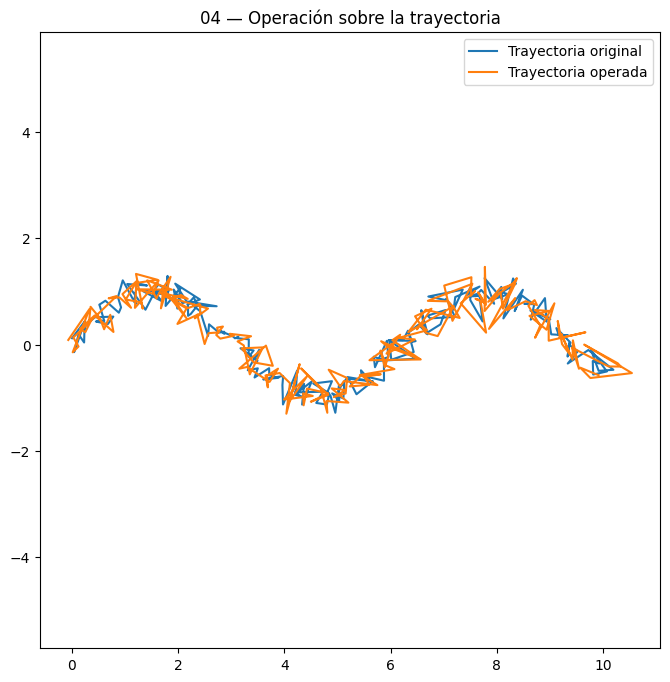

In [9]:
# ============================================================
# 04 — PRIMERA OPERACIÓN DE PRUEBA
# ============================================================

def aplicar_operacion(x, y, accion):
    """
    Modifica una trayectoria según una operación.
    """

    if accion == "desvio":
        # Introduce una pequeña desviación en el recorrido
        x = x + np.random.normal(0, 0.15, len(x))
        y = y + np.random.normal(0, 0.15, len(y))

    return x, y


# ------------------------------------------------------------
# PRUEBA
# ------------------------------------------------------------

x_operada, y_operada = aplicar_operacion(
    x,
    y,
    "desvio"
)

# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(8, 8))

plt.plot(x, y, label="Trayectoria original")
plt.plot(x_operada, y_operada, label="Trayectoria operada")

plt.axis("equal")
plt.legend()
plt.title("04 — Operación sobre la trayectoria")
plt.show()

la celda 05, donde hacemse hace que la operación de prueba afecte progresivamente a la trayectoria, antes de conectar las acciones reales del diccionario TTT2.

más controlado: que la operación no agregue ruido aleatorio cada vez, sino que produzca un desvío visible y reproducible en una parte de la trayectoria. Así se comienza a tener una operación que realmente modifica el recorrido.

Celda 05 — operación sobre un tramo

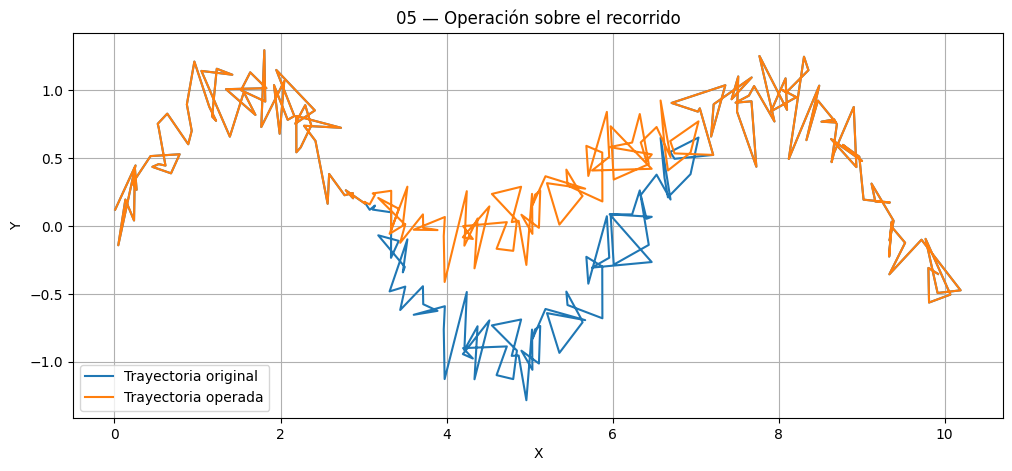

In [10]:
# ============================================================
# 05 — OPERACIÓN SOBRE UN TRAMO DE LA TRAYECTORIA
# ============================================================

def aplicar_operacion_tramo(x, y, inicio, fin, intensidad):
    """
    Desvía una parte de la trayectoria.

    inicio      → punto donde comienza la operación
    fin         → punto donde termina
    intensidad  → magnitud del desvío
    """

    x_nuevo = x.copy()
    y_nuevo = y.copy()

    # Crear una desviación progresiva
    tramo = np.linspace(0, np.pi, fin - inicio)

    y_nuevo[inicio:fin] += intensidad * np.sin(tramo)

    return x_nuevo, y_nuevo


# ------------------------------------------------------------
# APLICAR OPERACIÓN
# ------------------------------------------------------------

x_operada, y_operada = aplicar_operacion_tramo(
    x,
    y,
    inicio=60,
    fin=140,
    intensidad=1.0
)


# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(x, y, label="Trayectoria original")
plt.plot(x_operada, y_operada, label="Trayectoria operada")

plt.title("05 — Operación sobre el recorrido")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()

Ahora la lógica es:

TRAYECTORIA
     ↓
   TRAMO
     ↓
OPERACIÓN
     ↓
DESVÍO
     ↓
NUEVA TRAYECTORIA

Y esto es importante para el 02 porque ya tenemos un mecanismo operativo real al que posteriormente se puede conectar una unidad del diccionario:

UNIDAD TTT2
     ↓
ACCIÓN
     ↓
"DESVÍO"
     ↓
OPERACIÓN
     ↓
TRAYECTORIA

Por ahora "desvío" sigue siendo una operación de prueba

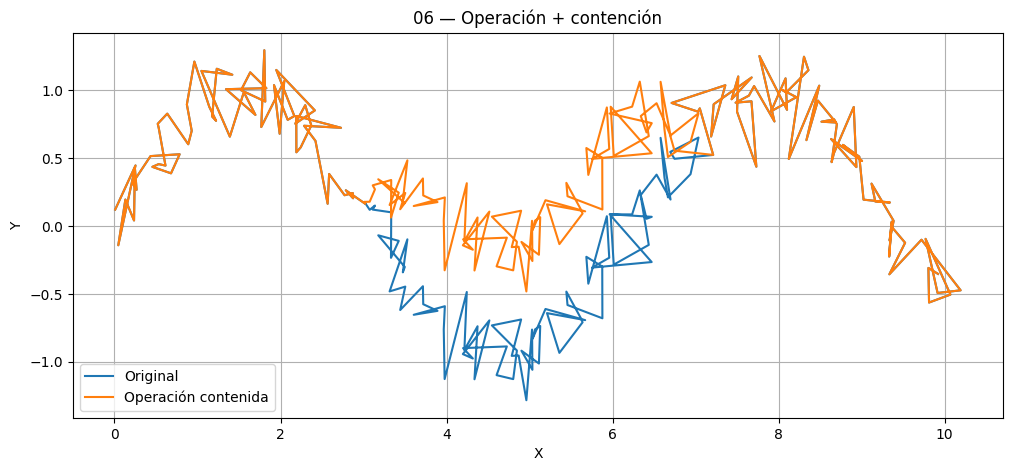

In [11]:
# ============================================================
# 06 — OPERACIÓN + CONTENCIÓN
# ============================================================

def aplicar_operacion_contenida(
    x,
    y,
    inicio,
    fin,
    intensidad,
    limite
):
    """
    Aplica una operación sobre un tramo de la trayectoria,
    manteniendo el desvío dentro de un límite.
    """

    x_nuevo = x.copy()
    y_nuevo = y.copy()

    tramo = np.linspace(0, np.pi, fin - inicio)

    # Desvío
    desvio = intensidad * np.sin(tramo)

    # Contención
    desvio = np.clip(
        desvio,
        -limite,
        limite
    )

    y_nuevo[inicio:fin] += desvio

    return x_nuevo, y_nuevo


# ------------------------------------------------------------
# PARÁMETROS DE LA OPERACIÓN
# ------------------------------------------------------------

inicio = 60
fin = 140

intensidad = 1.5
limite_operacion = 0.8


# ------------------------------------------------------------
# APLICAR
# ------------------------------------------------------------

x_contenida, y_contenida = aplicar_operacion_contenida(
    x,
    y,
    inicio,
    fin,
    intensidad,
    limite_operacion
)


# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(x, y, label="Original")
plt.plot(
    x_contenida,
    y_contenida,
    label="Operación contenida"
)

plt.title("06 — Operación + contención")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()

Ahora tenemos:

OPERACIÓN
    ↓
DESVÍO
    ↓
CONTENCIÓN
    ↓
RECORRIDO MODIFICADO

Y conceptualmente empieza a aparecer algo importante del 02:

La operación puede modificar el recorrido sin hacerlo de manera ilimitada.

La celda 07 incorpora ahora acumulación: la operación deja una huella que permanece en la trayectoria.
Esto permite empezar a pasar de una modificación puntual a un comportamiento que depende de lo ocurrido anteriormente.

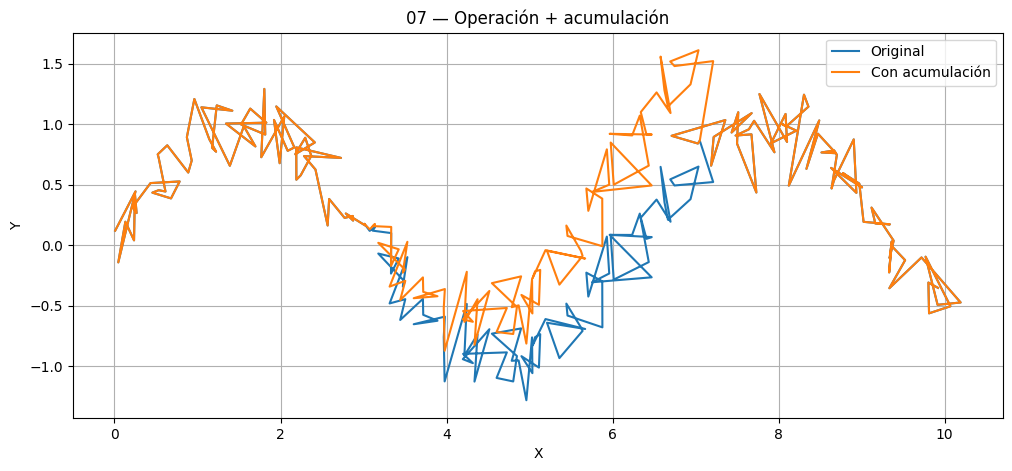

In [13]:
# ============================================================
# 07 — OPERACIÓN + ACUMULACIÓN
# ============================================================

def aplicar_acumulacion(y, inicio, fin, intensidad, memoria):
    """
    Aplica una operación cuya influencia se acumula
    progresivamente sobre la trayectoria.
    """

    y_nuevo = y.copy()

    tramo = np.linspace(0, 1, fin - inicio)

    # La influencia aumenta progresivamente
    acumulacion = intensidad * tramo * memoria

    y_nuevo[inicio:fin] += acumulacion

    return y_nuevo

    # La función toma una trayectoria, elige un tramo y
    # le aplica una influencia que comienza pequeña y aumenta progresivamente.


# ------------------------------------------------------------
# PARÁMETROS
# ------------------------------------------------------------

memoria = 1.0
intensidad_acumulacion = 1.0

inicio = 60
fin = 140


# ------------------------------------------------------------
# APLICAR
# ------------------------------------------------------------

y_acumulada = aplicar_acumulacion(
    y,
    inicio,
    fin,
    intensidad_acumulacion,
    memoria
)


# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(x, y, label="Original")
plt.plot(x, y_acumulada, label="Con acumulación")

plt.title("07 — Operación + acumulación")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()

La lógica ahora es:

OPERACIÓN
    ↓
CAMBIO
    ↓
ACUMULACIÓN
    ↓
EL ESTADO ANTERIOR
AFECTA EL RECORRIDO POSTERIOR

Y ya hay dos condiciones del 01 que pueden convertirse en comportamiento:

CONTENCIÓN → limita el cambio
ACUMULACIÓN → hace que el cambio permanezca

La siguiente celda puede incorporar ruido, y después hay que juntar las tres condiciones:

ruido + acumulación + contención → operación sobre la trenza.

08: ruido. Aquí se hace reproducible con una semilla, para que el comportamiento no cambie cada vez que se ejecuta el Colab.

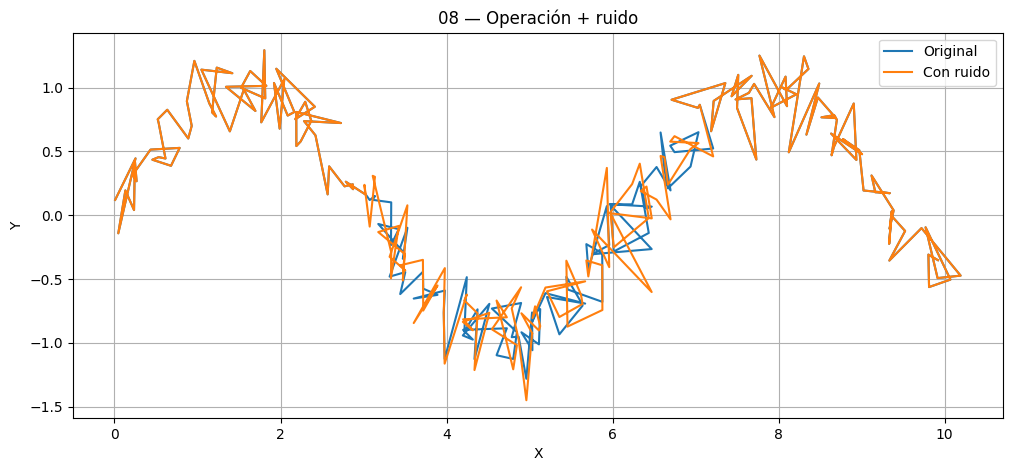

In [14]:
# ============================================================
# 08 — OPERACIÓN + RUIDO
# ============================================================

def aplicar_ruido(y, inicio, fin, intensidad, semilla=42):
    """
    Introduce una desviación aleatoria controlada
    sobre un tramo de la trayectoria.
    """

    y_nuevo = y.copy()

    rng = np.random.default_rng(semilla)

    ruido = rng.normal(
        0,
        intensidad,
        fin - inicio
    )

    y_nuevo[inicio:fin] += ruido

    return y_nuevo


# ------------------------------------------------------------
# PARÁMETROS
# ------------------------------------------------------------

inicio = 60
fin = 140

intensidad_ruido = 0.20


# ------------------------------------------------------------
# APLICAR
# ------------------------------------------------------------

y_ruido = aplicar_ruido(
    y,
    inicio,
    fin,
    intensidad_ruido
)


# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(x, y, label="Original")
plt.plot(x, y_ruido, label="Con ruido")

plt.title("08 — Operación + ruido")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.grid(True)

plt.show()

Ahora tenemos las tres condiciones separadas:

07 → ACUMULACIÓN
08 → RUIDO
06 → CONTENCIÓN

Y el siguiente paso importante será unificarlas en una sola operación, para que el 02 empiece a comportarse como el sistema que estamos buscando:

OPERACIÓN
    ↓
┌───────────────┐
│     RUIDO     │
│  ACUMULACIÓN  │
│  CONTENCIÓN   │
└───────────────┘
    ↓
TRAYECTORIA
    ↓
TRENZA

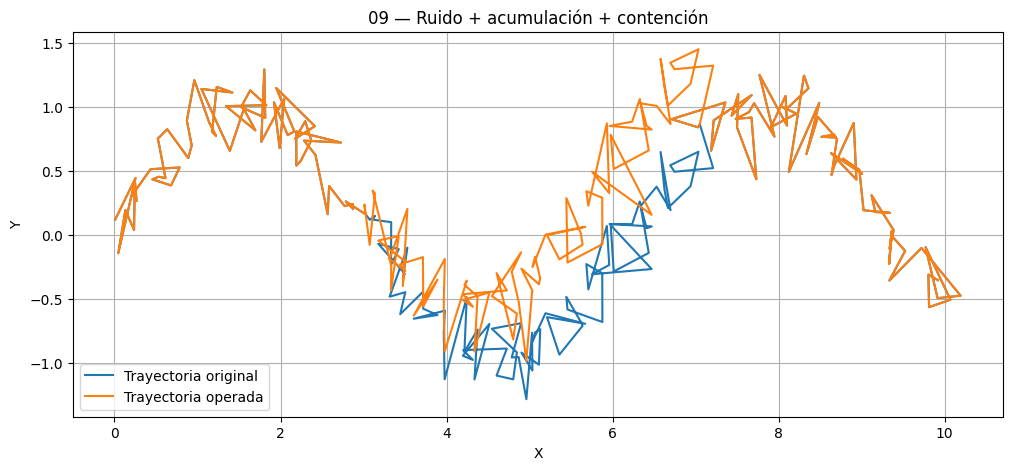

In [15]:
# Celda 09 — integrar ruido + acumulación + contención

# ============================================================
# 09 — OPERACIÓN INTEGRADA
# ============================================================

def aplicar_operacion_integrada(
    x,
    y,
    inicio,
    fin,
    intensidad_ruido,
    intensidad_acumulacion,
    limite,
    semilla=42
):
    """
    Integra tres condiciones en una misma operación:

    1. Ruido → introduce desviación
    2. Acumulación → conserva una influencia progresiva
    3. Contención → limita el desplazamiento
    """

    y_nuevo = y.copy()

    # --------------------------------------------------------
    # 1. RUIDO
    # --------------------------------------------------------

    rng = np.random.default_rng(semilla)

    ruido = rng.normal(
        0,
        intensidad_ruido,
        fin - inicio
    )

    # --------------------------------------------------------
    # 2. ACUMULACIÓN
    # --------------------------------------------------------

    acumulacion = np.linspace(
        0,
        intensidad_acumulacion,
        fin - inicio
    )

    # Combinar ruido + acumulación
    cambio = ruido + acumulacion

    # --------------------------------------------------------
    # 3. CONTENCIÓN
    # --------------------------------------------------------

    cambio = np.clip(
        cambio,
        -limite,
        limite
    )

    # --------------------------------------------------------
    # APLICAR AL RECORRIDO
    # --------------------------------------------------------

    y_nuevo[inicio:fin] += cambio

    return x.copy(), y_nuevo


# ------------------------------------------------------------
# PARÁMETROS
# ------------------------------------------------------------

inicio = 60
fin = 140

intensidad_ruido = 0.20
intensidad_acumulacion = 1.0
limite = 0.8


# ------------------------------------------------------------
# APLICAR OPERACIÓN
# ------------------------------------------------------------

x_integrada, y_integrada = aplicar_operacion_integrada(
    x,
    y,
    inicio,
    fin,
    intensidad_ruido,
    intensidad_acumulacion,
    limite
)


# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    x,
    y,
    label="Trayectoria original"
)

plt.plot(
    x_integrada,
    y_integrada,
    label="Trayectoria operada"
)

plt.title("09 — Ruido + acumulación + contención")

plt.xlabel("X")
plt.ylabel("Y")

plt.legend()
plt.grid(True)

plt.show()

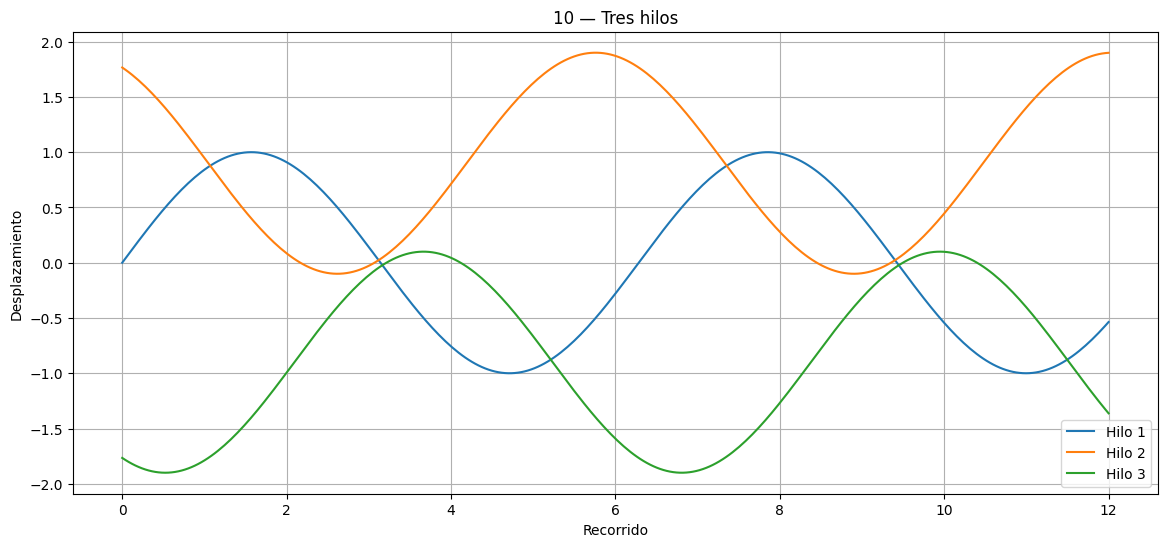

In [16]:
# ============================================================
# 10 — TRES HILOS / TRENZA
# ============================================================

# Parámetros
n_puntos = 300
t = np.linspace(0, 12, n_puntos)

# Tres hilos con el mismo recorrido base
# pero desplazados entre sí

amplitud = 1.0
separacion = 0.9

hilo_1 = amplitud * np.sin(t)

hilo_2 = amplitud * np.sin(t + 2 * np.pi / 3) + separacion
hilo_3 = amplitud * np.sin(t + 4 * np.pi / 3) - separacion


# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(t, hilo_1, label="Hilo 1")
plt.plot(t, hilo_2, label="Hilo 2")
plt.plot(t, hilo_3, label="Hilo 3")

plt.title("10 — Tres hilos")

plt.xlabel("Recorrido")
plt.ylabel("Desplazamiento")

plt.legend()
plt.grid(True)

plt.show()

Si la 10 ya recupera las tres curvas del experimento 01, entonces la 11 debe hacer que esas tres curvas se comporten como una trenza real. No se agrega ni una relacion con TTT2_diccionario aun

Celda 11 — entrelazamiento de los tres hilos

la celda 11 solo se construye la geometría base de los tres hilos mediante fases regulares.

Aun no se aplican las operaciones de ruido, acumulación/entropía y contención a estos tres hilos.

CELDA 11
GEOMETRÍA
    ↓
3 HILOS
    ↓
ENTRELAZAMIENTO
    ↓
TRENZA BASE

Todavía sin:

RUIDO
ACUMULACIÓN / ENTROPÍA
CONTENCIÓN

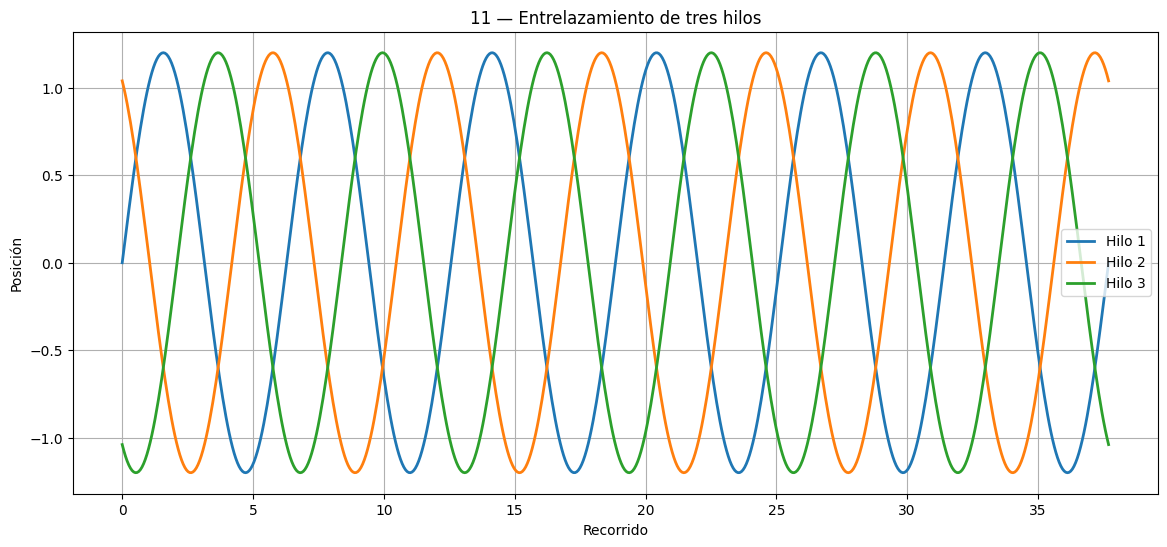

In [18]:
# ============================================================
# 11 — ENTRELAZAMIENTO DE LOS TRES HILOS
# ============================================================

# Cada hilo conserva su identidad,
# pero los tres recorren el mismo espacio.
#
# La posición vertical cambia de manera periódica,
# haciendo que los hilos se crucen entre sí.

n_puntos = 600
t = np.linspace(0, 12 * np.pi, n_puntos)

amplitud = 1.0
separacion = 1.2

# Movimiento común de la trenza
base = np.sin(t)

# Tres fases diferentes
fase_1 = 0
fase_2 = 2 * np.pi / 3
fase_3 = 4 * np.pi / 3

# Tres hilos
hilo_1 = separacion * np.sin(t + fase_1)
hilo_2 = separacion * np.sin(t + fase_2)
hilo_3 = separacion * np.sin(t + fase_3)

# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

plt.plot(t, hilo_1, linewidth=2, label="Hilo 1")
plt.plot(t, hilo_2, linewidth=2, label="Hilo 2")
plt.plot(t, hilo_3, linewidth=2, label="Hilo 3")

plt.title("11 — Entrelazamiento de tres hilos")
plt.xlabel("Recorrido")
plt.ylabel("Posición")

plt.legend()
plt.grid(True)

plt.show()

Aca RECIEN se juntan los tres conceptos sobre los tres hilos. Aquí ya debería aparecer una trenza menos simétrica.

Celda 12 — ruido + acumulación + contención sobre la trenza

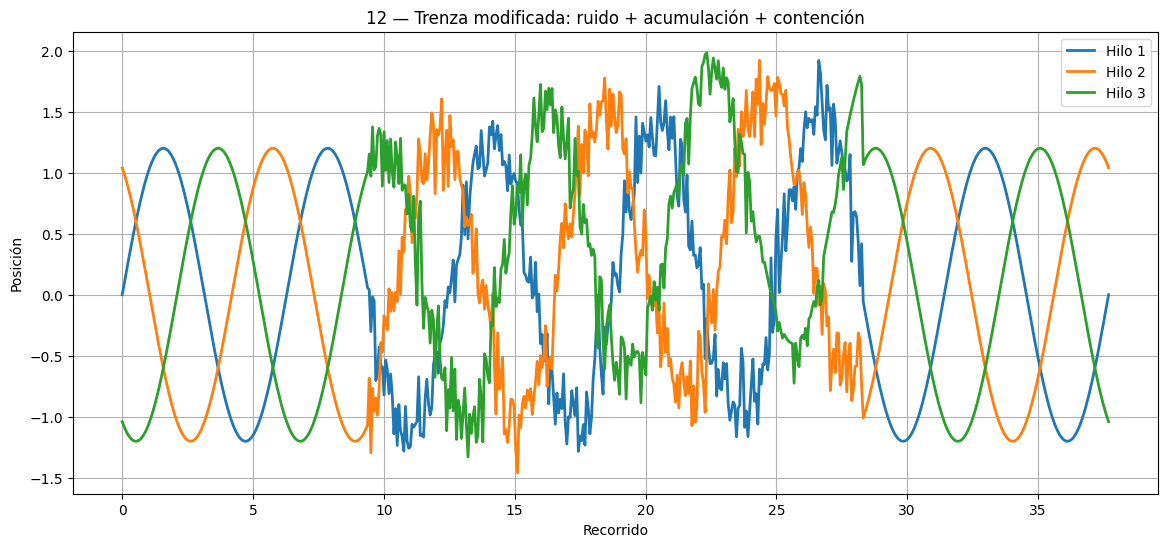

In [19]:
# ============================================================
# 12 — OPERACIONES SOBRE LOS TRES HILOS
# ============================================================

def operar_trenza(
    hilos,
    inicio,
    fin,
    intensidad_ruido,
    intensidad_acumulacion,
    limite,
    semilla=42
):
    """
    Aplica sobre los tres hilos:

    - ruido
    - acumulación
    - contención

    Cada hilo recibe una variación diferente.
    """

    rng = np.random.default_rng(semilla)

    hilos_nuevos = []

    for i, hilo in enumerate(hilos):

        hilo_nuevo = hilo.copy()

        # ----------------------------------------------------
        # RUIDO
        # ----------------------------------------------------

        ruido = rng.normal(
            0,
            intensidad_ruido,
            fin - inicio
        )

        # ----------------------------------------------------
        # ACUMULACIÓN
        # ----------------------------------------------------

        acumulacion = np.linspace(
            0,
            intensidad_acumulacion * (i + 1) / len(hilos),
            fin - inicio
        )

        # ----------------------------------------------------
        # COMBINAR
        # ----------------------------------------------------

        cambio = ruido + acumulacion

        # ----------------------------------------------------
        # CONTENCIÓN
        # ----------------------------------------------------

        cambio = np.clip(
            cambio,
            -limite,
            limite
        )

        hilo_nuevo[inicio:fin] += cambio

        hilos_nuevos.append(hilo_nuevo)

    return hilos_nuevos


# ------------------------------------------------------------
# AGRUPAR LOS TRES HILOS DE LA CELDA 11
# ------------------------------------------------------------

hilos = [
    hilo_1,
    hilo_2,
    hilo_3
]


# ------------------------------------------------------------
# APLICAR OPERACIONES
# ------------------------------------------------------------

hilos_operados = operar_trenza(
    hilos,
    inicio=150,
    fin=450,
    intensidad_ruido=0.20,
    intensidad_acumulacion=1.0,
    limite=0.8
)


# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------

plt.figure(figsize=(14, 6))

for i, hilo in enumerate(hilos_operados):
    plt.plot(
        t,
        hilo,
        linewidth=2,
        label=f"Hilo {i + 1}"
    )

plt.title(
    "12 — Trenza modificada: "
    "ruido + acumulación + contención"
)

plt.xlabel("Recorrido")
plt.ylabel("Posición")

plt.legend()
plt.grid(True)

plt.show()

En la 13:  las 24 unidades puedan actuar como entradas del sistema, pero todavía sin inventar las acciones reales de TTT2.

In [20]:
# ============================================================
# 13 — UNIDAD TTT2 COMO ENTRADA DE OPERACIÓN
# ============================================================

# Seleccionamos una unidad del diccionario
unidad_seleccionada = 1

# Recuperar sus datos
unidad = diccionario[unidad_seleccionada]

print("Unidad seleccionada:", unidad["unidad"])
print("Acción:", unidad["accion"])
print("Efecto:", unidad["efecto"])

Unidad seleccionada: 1
Acción: None
Efecto: None


so es solo la estructura del sistema.

Para que el experimento 02 sea fiel a TTT2, el siguiente paso debería ser:

DICCIONARIO TTT2 REAL
        ↓
24 UNIDADES
        ↓
ACCIÓN / REACCIÓN
        ↓
TRADUCCIÓN OPERACIONAL
        ↓
TRAYECTORIA
        ↓
TRENZA

Y aquí sí se necesita PDF del diccionario, porque hay que extraer las 24 unidades y sus acciones/reacciones tal como aparecen en TTT2, no inventarlas.

In [21]:
# ============================================================
# 14 — DICCIONARIO REAL TTT2
# ============================================================

diccionario_ttt2 = {

    "A": "Acción",
    "B": "Bifurcar",
    "C": "Conectar",
    "D": "Decodificar",
    "E": "Encriptar",
    "F": "Filtrar",
    "G": "Generar",
    "H": "Hibridar",
    "I": "Iterar",
    "J": "Juntar",
    "K": "Kinesis",
    "L": "Layer",

    "M": "Mapear",
    "N": "Neutralizar",
    "O": "Organizar",
    "P": "Procesar",
    "Q": "Query",
    "R": "Reconfigurar",
    "S": "Simplificar",
    "T": "Transcodificar",
    "V": "Verificar",
    "W": "Warp",
    "X": "Expandir",
    "Z": "Zonar"
}


# ------------------------------------------------------------
# COMPROBACIÓN
# ------------------------------------------------------------

print("Unidades TTT2:", len(diccionario_ttt2))

for letra, accion in diccionario_ttt2.items():
    print(f"{letra} → {accion}")

Unidades TTT2: 24
A → Acción
B → Bifurcar
C → Conectar
D → Decodificar
E → Encriptar
F → Filtrar
G → Generar
H → Hibridar
I → Iterar
J → Juntar
K → Kinesis
L → Layer
M → Mapear
N → Neutralizar
O → Organizar
P → Procesar
Q → Query
R → Reconfigurar
S → Simplificar
T → Transcodificar
V → Verificar
W → Warp
X → Expandir
Z → Zonar


El 01 preguntaba, en términos muy generales:

¿Qué ocurre cuando una estructura está sometida a contención, ruido y entropía?

El 02 puede avanzar hacia:

¿Qué ocurre cuando las unidades del diccionario pueden combinarse y ejecutar operaciones sobre esa estructura?

Entonces:

CONDICIONES

Contención + Ruido + Entropía

↓

OPERACIONES

Bifurcar + Mapear + Reconfigurar

↓

COMPORTAMIENTO

una dinámica que emerge de la combinación.

4. Y esto explica por qué el 02 todavía puede verse tan simétrico

En la etapa de antes de introducir realmente acciones y operaciones— las unidades todavía pueden aparecer como estructuras combinatorias relativamente neutras.